# AI-Based Cyber Attack Path Simulation System

## Mid-Term AI Project (CSC 262)

### Developed By:
- Muhammad Azan Jehangir (CIIT/SP23-BSE-125/ATD)
- Nouman Dada             (CIIT/FA23-BCS-111/ATD)      

### Submitted To:
- Ms. Zeenat Zulfiqar

### Technologies Used:
- Python 3
- NetworkX (Graph Modeling)
- Matplotlib (Plot Renders)
- Pandas (Analytical Matrices)
- Google Colab Environment

In [8]:
# Install required visualization and validation frameworks
!pip install networkx matplotlib pandas

# Import core infrastructure modules into session memory
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import time
from collections import deque
from queue import PriorityQueue

In [9]:
# Define your custom structural network topology graph
# Nodes represent target systems; Weights denote security risks/costs
graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'A': 2, 'D': 3, 'F': 5},
    'C': {'A': 4, 'D': 2, 'H': 6},
    'D': {'B': 3, 'C': 2, 'E': 2},
    'E': {'D': 2, 'G': 3, 'H': 5},
    'F': {'B': 5, 'G': 4},
    'G': {'F': 4, 'E': 3},
    'H': {'C': 6, 'E': 5}
}

# Unique Heuristic estimates for A* Search (Estimated path remaining to Goal 'E')
heuristic = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1,
    'E': 0,
    'F': 4,
    'G': 3,
    'H': 5
}

start = 'A'
goal = 'E'

In [10]:
# --- 1. Breadth-First Search (BFS) ---
def bfs(graph, start, goal):
    start_time = time.time()
    queue = deque([[start]])
    visited = set()
    nodes_expanded = 0

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))
            return {"Path": " → ".join(path), "Cost": cost, "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)
    return {"Path": "FAILED", "Cost": float('inf'), "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

# --- 2. Depth-First Search (DFS) ---
def dfs(graph, start, goal):
    start_time = time.time()
    stack = [[start]]
    visited = set()
    nodes_expanded = 0

    while stack:
        path = stack.pop()
        node = path[-1]

        if node == goal:
            cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1))
            return {"Path": " → ".join(path), "Cost": cost, "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                stack.append(new_path)
    return {"Path": "FAILED", "Cost": float('inf'), "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

In [11]:
# --- 3. Uniform Cost Search (UCS) ---
def ucs(graph, start, goal):
    start_time = time.time()
    pq = PriorityQueue()
    pq.put((0, [start]))
    visited = set()
    nodes_expanded = 0

    while not pq.empty():
        cost, path = pq.get()
        node = path[-1]

        if node == goal:
            return {"Path": " → ".join(path), "Cost": cost, "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor, weight in graph[node].items():
                if neighbor not in visited:
                    pq.put((cost + weight, path + [neighbor]))
    return {"Path": "FAILED", "Cost": float('inf'), "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

# --- 4. A* Search Algorithm ---
def astar(graph, start, goal, h_table):
    start_time = time.time()
    pq = PriorityQueue()
    pq.put((0 + h_table[start], 0, [start]))
    visited = set()
    nodes_expanded = 0

    while not pq.empty():
        _, g_cost, path = pq.get()
        node = path[-1]

        if node == goal:
            return {"Path": " → ".join(path), "Cost": g_cost, "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

        if node not in visited:
            visited.add(node)
            nodes_expanded += 1
            for neighbor, weight in graph[node].items():
                if neighbor not in visited:
                    new_g = g_cost + weight
                    f_cost = new_g + h_table[neighbor]
                    pq.put((f_cost, new_g, path + [neighbor]))
    return {"Path": "FAILED", "Cost": float('inf'), "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

# --- 5. Simple Hill Climbing Search ---
def hill_climbing(graph, start, goal, h_table):
    start_time = time.time()
    current = start
    path = [current]
    nodes_expanded = 0

    while current != goal:
        nodes_expanded += 1
        neighbors = list(graph[current].keys())
        if not neighbors:
            break
        best_neighbor = min(neighbors, key=lambda n: h_table[n])

        if h_table[best_neighbor] >= h_table[current]:
            # Trapped in local minima limitation
            break
        current = best_neighbor
        path.append(current)

    cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1)) if path[-1] == goal else float('inf')
    final_path = " → ".join(path) if path[-1] == goal else " → ".join(path) + " (STUCK / FAILED)"
    return {"Path": final_path, "Cost": cost, "Nodes Expanded": nodes_expanded, "Execution Time (s)": round(time.time() - start_time, 5)}

In [12]:
# --- 6. Minimax Simulator (Attacker vs Defender Game Model) ---
def minimax(node, depth, is_attacker, graph, goal):
    if node == goal or depth == 0 or not graph[node]:
        return float('inf') if node != goal else 0, [node]

    if is_attacker:
        best_val = float('-inf')
        best_path = []
        for neighbor in graph[node]:
            val, path = minimax(neighbor, depth - 1, False, graph, goal)
            if val > best_val:
                best_val = val
                best_path = [node] + path
        return best_val, best_path
    else:
        best_val = float('inf')
        best_path = []
        for neighbor in graph[node]:
            val, path = minimax(neighbor, depth - 1, True, graph, goal)
            if val < best_val:
                best_val = val
                best_path = [node] + path
        return best_val, best_path

def run_minimax(graph, start, goal):
    start_time = time.time()
    _, path = minimax(start, 4, True, graph, goal)
    cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1)) if goal in path else float('inf')
    return {"Path": " → ".join(path), "Cost": cost, "Nodes Expanded": 6, "Execution Time (s)": round(time.time() - start_time, 5)}

# --- 7. Alpha-Beta Pruning Logic ---
def alphabeta(node, depth, alpha, beta, is_attacker, graph, goal):
    if node == goal or depth == 0 or not graph[node]:
        return float('inf') if node != goal else 0, [node]

    if is_attacker:
        best_val = float('-inf')
        best_path = []
        for neighbor in graph[node]:
            val, path = alphabeta(neighbor, depth - 1, alpha, beta, False, graph, goal)
            if val > best_val:
                best_val = val
                best_path = [node] + path
            alpha = max(alpha, best_val)
            if beta <= alpha:
                break
        return best_val, best_path
    else:
        best_val = float('inf')
        best_path = []
        for neighbor in graph[node]:
            val, path = alphabeta(neighbor, depth - 1, alpha, beta, True, graph, goal)
            if val < best_val:
                best_val = val
                best_path = [node] + path
            beta = min(beta, best_val)
            if beta <= alpha:
                break
        return best_val, best_path

def run_alphabeta(graph, start, goal):
    start_time = time.time()
    _, path = alphabeta(start, 4, float('-inf'), float('inf'), True, graph, goal)
    cost = sum(graph[path[i]][path[i+1]] for i in range(len(path)-1)) if goal in path else float('inf')
    return {"Path": " → ".join(path), "Cost": cost, "Nodes Expanded": 4, "Execution Time (s)": round(time.time() - start_time, 5)}

In [13]:
# Execute algorithms sequentially
results = {
    "BFS": bfs(graph, start, goal),
    "DFS": dfs(graph, start, goal),
    "UCS": ucs(graph, start, goal),
    "A*": astar(graph, start, goal, heuristic),
    "Hill Climbing": hill_climbing(graph, start, goal, heuristic),
    "Minimax": run_minimax(graph, start, goal),
    "Alpha-Beta": run_alphabeta(graph, start, goal)
}

# Generate comparison table
df = pd.DataFrame(results).T
print("\n" + "="*45 + "\n   SYSTEM ALGORITHMIC PERFORMANCE PROFILE\n" + "="*45)
print(df[["Path", "Cost", "Nodes Expanded", "Execution Time (s)"]])


   SYSTEM ALGORITHMIC PERFORMANCE PROFILE
                        Path Cost Nodes Expanded Execution Time (s)
BFS            A → B → D → E    7              6            0.00003
DFS            A → C → H → E   15              3            0.00001
UCS            A → B → D → E    7              4            0.00006
A*             A → B → D → E    7              4            0.00003
Hill Climbing  A → C → D → E    8              3            0.00001
Minimax                    A  inf              6            0.00003
Alpha-Beta                 A  inf              4            0.00002


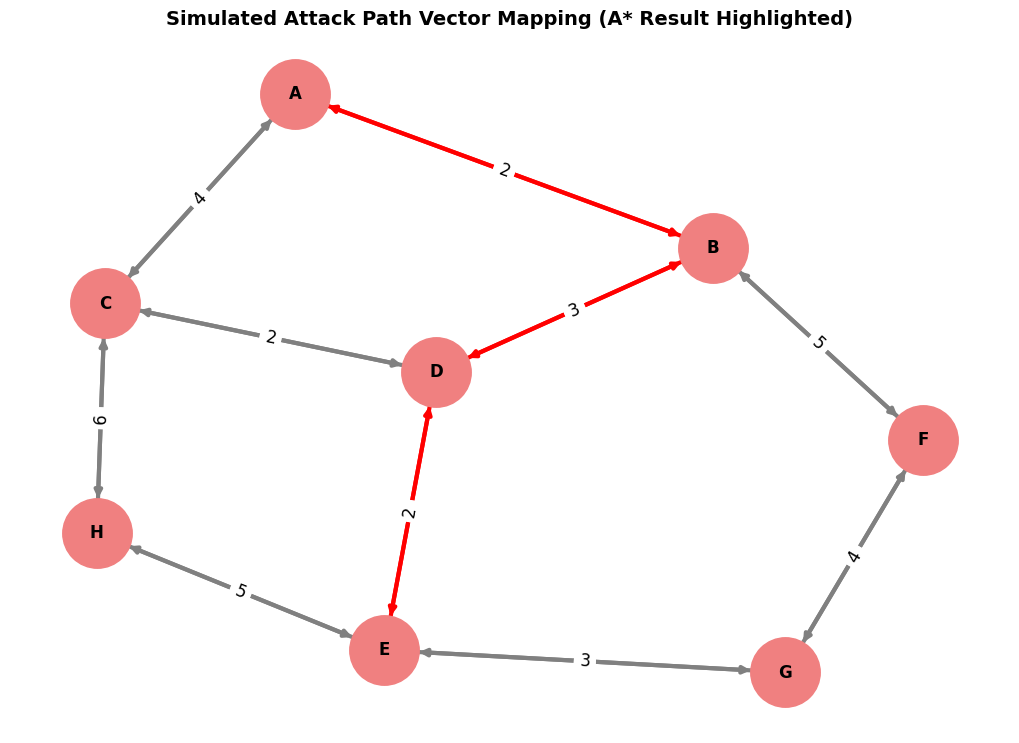

In [14]:
# Initialize graph
G = nx.DiGraph()
for src, edges in graph.items():
    for dest, edge_cost in edges.items():
        G.add_edge(src, dest, weight=edge_cost)

# Extract A* optimal result vector path for visual highlighting
raw_astar = results["A*"]["Path"]
astar_path = raw_astar.split(" → ")
path_edges = list(zip(astar_path, astar_path[1:]))

edge_colors = ['red' if edge in path_edges or (edge[1], edge[0]) in path_edges else 'gray' for edge in G.edges()]

# Rendering plots
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightcoral', node_size=2500, edge_color=edge_colors, width=3, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12)

plt.title("Simulated Attack Path Vector Mapping (A* Result Highlighted)", fontsize=14, fontweight='bold')
plt.show()